In [1]:
# Restart kernel, then re-run Cell 1 fresh
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')
engine = create_engine(os.getenv('DATABASE_URL'), pool_pre_ping=True)

In [2]:
query = """
SELECT latitude, longitude, crime_type, hour, day_of_week
FROM crime_incidents
WHERE crime_type = 'THEFT'
ORDER BY RANDOM()
LIMIT 50000
"""
df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(50000, 5)


,latitude,longitude,crime_type,hour,day_of_week
0,41.978527,-87.757087,THEFT,11,2
1,41.699642,-87.715774,THEFT,21,3
2,41.938311,-87.716141,THEFT,16,2
3,41.818351,-87.622473,THEFT,23,3
4,41.855914,-87.670103,THEFT,13,5


In [6]:
coords = df[['latitude', 'longitude']].values

# eps in degrees ~ roughly 300-400 meters at Chicago's latitude
db = DBSCAN(eps=0.0015, min_samples=40, metric='euclidean')
df['cluster'] = db.fit_predict(coords)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise = list(df['cluster']).count(-1)

print(f"Number of hotspot clusters: {n_clusters}")
print(f"Noise points (not in any cluster): {n_noise}")

Number of hotspot clusters: 86
Noise points (not in any cluster): 36597


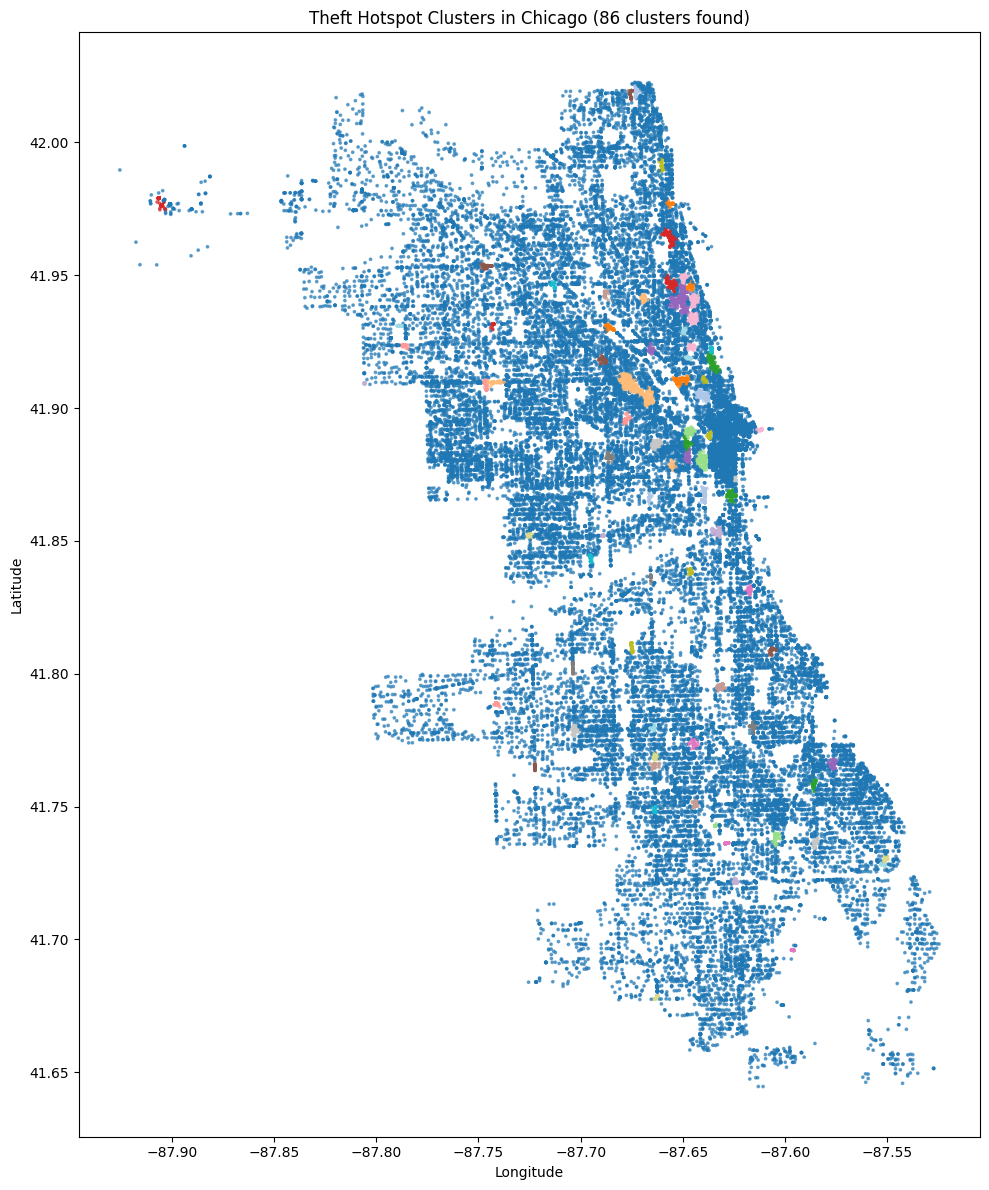

In [7]:
plt.figure(figsize=(10, 12))
scatter = plt.scatter(
    df['longitude'], df['latitude'], 
    c=df['cluster'], cmap='tab20', s=3, alpha=0.6
)
plt.title(f'Theft Hotspot Clusters in Chicago ({n_clusters} clusters found)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [8]:
cluster_summary = df[df['cluster'] != -1].groupby('cluster').agg(
    center_lat=('latitude', 'mean'),
    center_lon=('longitude', 'mean'),
    crime_count=('cluster', 'size')
).sort_values('crime_count', ascending=False)

print(cluster_summary.head(10))

         center_lat  center_lon  crime_count
cluster                                     
1         41.888337  -87.627640         5532
37        41.940468  -87.650858          419
13        41.909089  -87.675873          407
2         41.754597  -87.741526          272
4         41.867216  -87.639348          252
16        41.909662  -87.742200          216
26        41.963740  -87.656289          215
23        41.880209  -87.640453          204
9         41.910316  -87.651277          185
15        41.903873  -87.666966          166


In [9]:
import json

hotspots_geojson = {
    "type": "FeatureCollection",
    "features": []
}

for cluster_id, row in cluster_summary.iterrows():
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['center_lon'], row['center_lat']]
        },
        "properties": {
            "cluster_id": int(cluster_id),
            "crime_count": int(row['crime_count']),
            "crime_type": "THEFT"
        }
    }
    hotspots_geojson["features"].append(feature)

with open('../data/geojson/theft_hotspots.geojson', 'w') as f:
    json.dump(hotspots_geojson, f, indent=2)

print(f"Exported {len(hotspots_geojson['features'])} hotspots to GeoJSON")

Exported 86 hotspots to GeoJSON


In [10]:
cluster_summary.to_csv('../data/processed/theft_hotspot_clusters.csv')
print("Saved cluster summary")

Saved cluster summary


In [11]:
def detect_hotspots(crime_type, eps=0.0015, min_samples=40, sample_size=50000):
    query = f"""
    SELECT latitude, longitude, crime_type
    FROM crime_incidents
    WHERE crime_type = '{crime_type}'
    ORDER BY RANDOM()
    LIMIT {sample_size}
    """
    df = pd.read_sql(query, engine)
    
    coords = df[['latitude', 'longitude']].values
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    df['cluster'] = db.fit_predict(coords)
    
    n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
    
    summary = df[df['cluster'] != -1].groupby('cluster').agg(
        center_lat=('latitude', 'mean'),
        center_lon=('longitude', 'mean'),
        crime_count=('cluster', 'size')
    ).sort_values('crime_count', ascending=False)
    
    print(f"{crime_type}: {n_clusters} clusters found, top cluster size: {summary['crime_count'].max()}")
    
    return df, summary

In [12]:
battery_df, battery_clusters = detect_hotspots('BATTERY')
damage_df, damage_clusters = detect_hotspots('CRIMINAL DAMAGE')
narcotics_df, narcotics_clusters = detect_hotspots('NARCOTICS')

BATTERY: 96 clusters found, top cluster size: 600
CRIMINAL DAMAGE: 25 clusters found, top cluster size: 273
NARCOTICS: 96 clusters found, top cluster size: 6860


In [13]:
all_crime_data = {
    'THEFT': cluster_summary,
    'BATTERY': battery_clusters,
    'CRIMINAL DAMAGE': damage_clusters,
    'NARCOTICS': narcotics_clusters
}

combined_geojson = {
    "type": "FeatureCollection",
    "features": []
}

for crime_type, summary in all_crime_data.items():
    for cluster_id, row in summary.iterrows():
        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [row['center_lon'], row['center_lat']]
            },
            "properties": {
                "cluster_id": int(cluster_id),
                "crime_count": int(row['crime_count']),
                "crime_type": crime_type
            }
        }
        combined_geojson["features"].append(feature)

with open('../data/geojson/all_hotspots.geojson', 'w') as f:
    json.dump(combined_geojson, f, indent=2)

print(f"Exported {len(combined_geojson['features'])} total hotspots across {len(all_crime_data)} crime types")

Exported 303 total hotspots across 4 crime types


In [14]:
battery_clusters.to_csv('../data/processed/battery_hotspot_clusters.csv')
damage_clusters.to_csv('../data/processed/damage_hotspot_clusters.csv')
narcotics_clusters.to_csv('../data/processed/narcotics_hotspot_clusters.csv')

print("Saved all crime-type cluster summaries")

Saved all crime-type cluster summaries
